---
---

## Introduction

In this first laboratory we will see a few ways to exploit and adapt pre-trained models to solve new problems. We will start first by downloading and instantiating a new dataset and establishing a stable and reproducible baseline model based on a pre-trained CNN.

---

## Exercise 1 (Warmup): Exploratory Data Analysis and a Stable Baseline

For this laboratory we will work with [The German Traffic Sign Detection Benchmark](https://benchmark.ini.rub.de/) [1]. We will begin, not with *detection*, but with a simpler traffic sign *classification* problem. This has two advantages: (1) the images are *smaller* than in the detection benchmark; and (2) a wrapper for the GTSRB dataset is conveniently included in the `torchvision` library.  

[1] Houben S, Stallkamp J, Salmen J, Schlipsing M, Igel C. Detection of traffic signs in real-world images: The German Traffic Sign Detection Benchmark. In The 2013 International Joint Conference on Neural Networks (IJCNN), 2013.

### Exercise 1.1: Exploratory Data Analysis

A good best practice to adopt in all experimental deep learning projects is thorough *exploratory data analysis*. In this exercise you should instantiate the GTSRB Dataset, inspect some images, and do some statistical analysis of the distribution of data (and metadata). A goal here is to keep an eye out for anything that might be problematic in what is to come.


1. Environment Setup and Imports

In [2]:

import os
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torchvision.transforms.v2 as T
from torchvision.datasets import GTSRB

from IPython.display import display

# Seed for reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Device selection
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device: {device}")

Device: cuda


2. Loading the Raw GTSRB Dataset

In [3]:

DATA_DIR = "data/"

# Raw datasets are loaded without transformations.
# This allows us to inspect the original images and their metadata.
ds_train_raw = GTSRB(
    root=DATA_DIR,
    split="train",
    transform=None,
    download=True
)

ds_test_raw = GTSRB(
    root=DATA_DIR,
    split="test",
    transform=None,
    download=True
)

print(f"Training samples: {len(ds_train_raw)}")
print(f"Test samples:     {len(ds_test_raw)}")

Training samples: 26640
Test samples:     12630


3. Inspecting Image Sizes

In [4]:
# PIL image size is expressed as (width, height).
first_image, first_label = ds_train_raw[0]
second_image, second_label = ds_train_raw[1]

print(f"First image size:  {first_image.size}, class: {first_label}")
print(f"Second image size: {second_image.size}, class: {second_label}")

First image size:  (29, 30), class: 0
Second image size: (30, 30), class: 0


 4. Visual Inspection of Raw Images

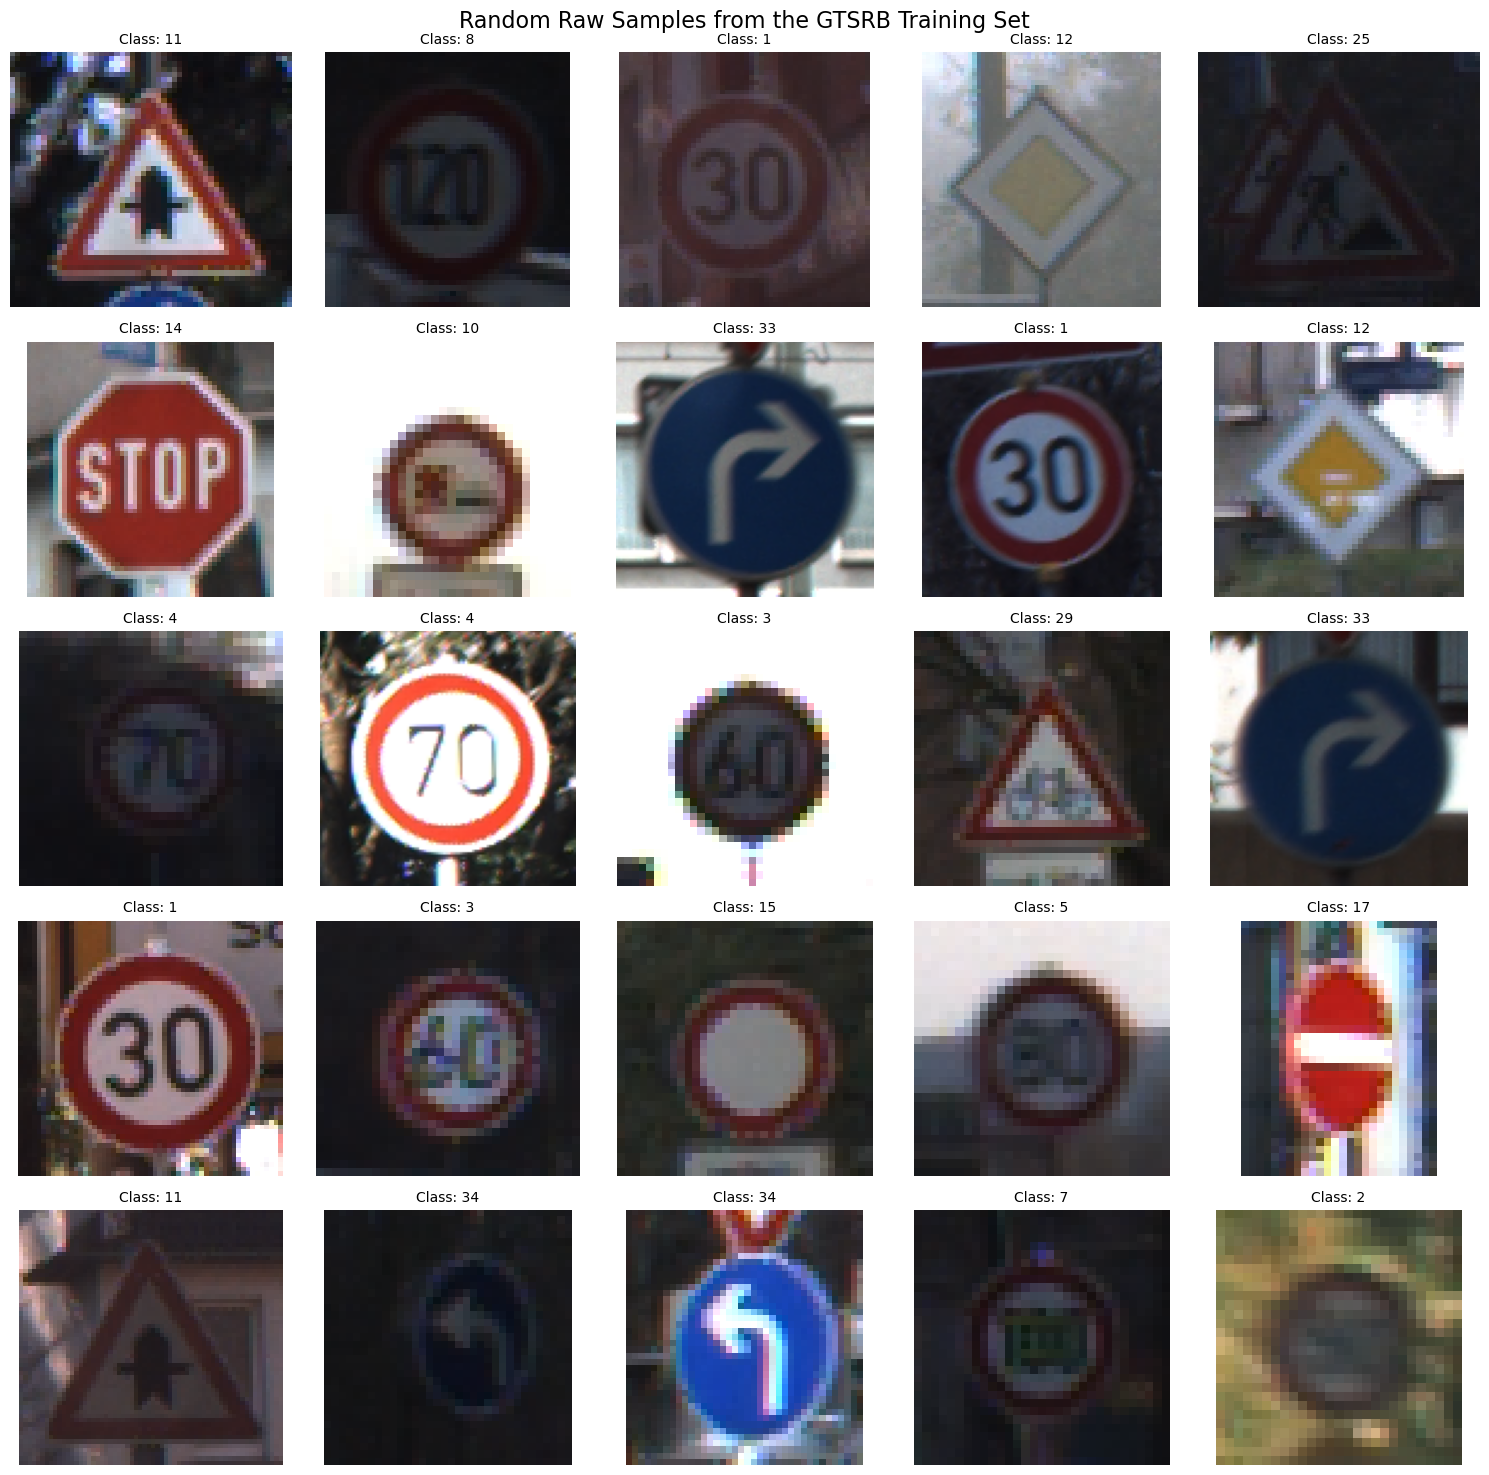

In [5]:

num_samples = 25
random_indices = np.random.choice(len(ds_train_raw), num_samples, replace=False)

plt.figure(figsize=(15, 15))

for idx, sample_idx in enumerate(random_indices):
    image, label = ds_train_raw[sample_idx]

    plt.subplot(5, 5, idx + 1)
    plt.imshow(image)
    plt.title(f"Class: {label}", fontsize=10)
    plt.axis("off")

plt.suptitle("Random Raw Samples from the GTSRB Training Set", fontsize=16)
plt.tight_layout()
plt.show()

In [6]:
cache_path = "df_stats_cache.csv"

if os.path.exists(cache_path):
    print("Loading dataset statistics from cache...")
    df_stats = pd.read_csv(cache_path)
else:
    print("Computing dataset statistics...")

    # For each image we store:
    # - class label
    # - image height
    # - image width
    # - aspect ratio
    df_stats = pd.DataFrame(
        [
            (label, image.size[1], image.size[0])
            for image, label in ds_train_raw
        ],
        columns=["CLS", "HEIGHT", "WIDTH"]
    )

    df_stats["AR"] = df_stats["WIDTH"] / df_stats["HEIGHT"]

    df_stats.to_csv(cache_path, index=False)
    print(f"Statistics saved to {cache_path}")

display(df_stats.head())

Loading dataset statistics from cache...


,CLS,HEIGHT,WIDTH,AR
0,0,30,29,0.966667
1,0,30,30,1.000000
2,0,30,30,1.000000
3,0,31,31,1.000000
4,0,32,30,0.937500


,HEIGHT,WIDTH,AR
count,26640.000000,26640.000000,26640.000000
mean,50.365128,50.933784,1.008718
std,23.161523,24.373418,0.072100
min,25.000000,25.000000,0.368132
25%,35.000000,35.000000,0.972222
50%,43.000000,43.000000,1.000000
75%,58.000000,58.000000,1.044444
max,225.000000,243.000000,1.417808


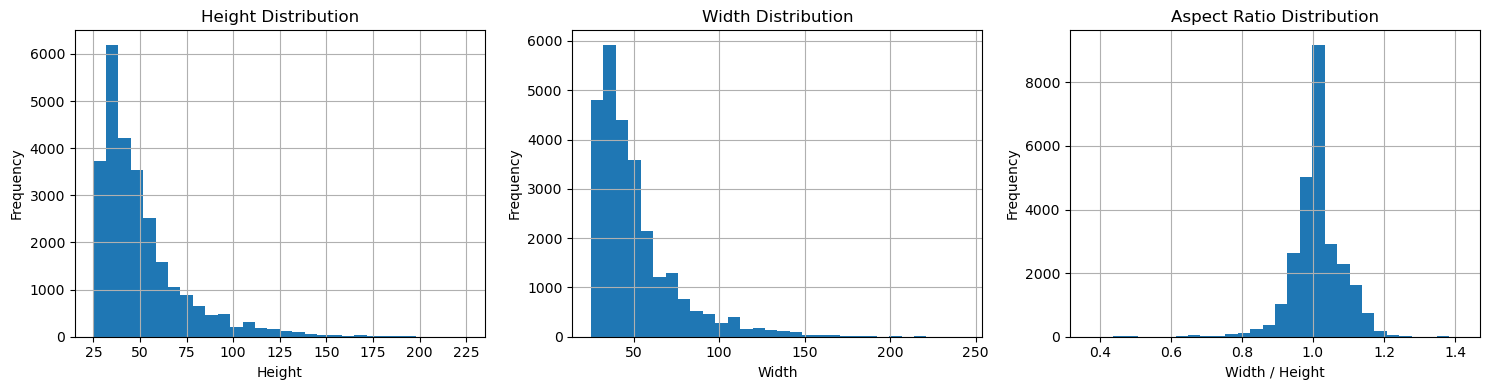

In [7]:
display(df_stats[["HEIGHT", "WIDTH", "AR"]].describe())

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df_stats["HEIGHT"].hist(ax=axes[0], bins=30)
axes[0].set_title("Height Distribution")
axes[0].set_xlabel("Height")
axes[0].set_ylabel("Frequency")

df_stats["WIDTH"].hist(ax=axes[1], bins=30)
axes[1].set_title("Width Distribution")
axes[1].set_xlabel("Width")
axes[1].set_ylabel("Frequency")

df_stats["AR"].hist(ax=axes[2], bins=30)
axes[2].set_title("Aspect Ratio Distribution")
axes[2].set_xlabel("Width / Height")
axes[2].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

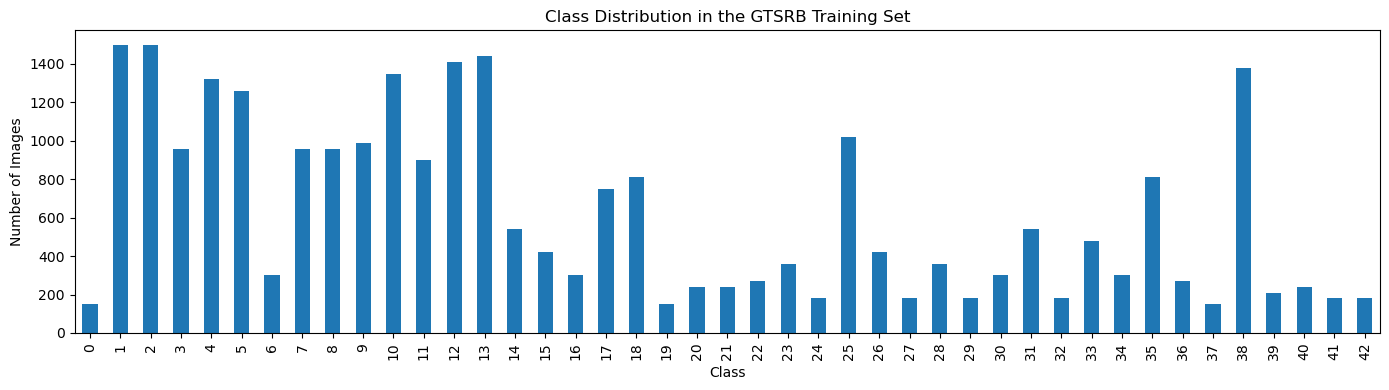

Number of classes: 43
Labels range from 0 to 42
Least represented class: 0 with 150 images
Most represented class:  1 with 1500 images


In [8]:
class_counts = df_stats["CLS"].value_counts().sort_index()

plt.figure(figsize=(14, 4))
class_counts.plot(kind="bar")
plt.title("Class Distribution in the GTSRB Training Set")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.show()

print(f"Number of classes: {df_stats['CLS'].nunique()}")
print(f"Labels range from {df_stats['CLS'].min()} to {df_stats['CLS'].max()}")
print(f"Least represented class: {class_counts.idxmin()} with {class_counts.min()} images")
print(f"Most represented class:  {class_counts.idxmax()} with {class_counts.max()} images")

 Preprocessing Pipeline Definition


In [9]:

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

transform = T.Compose([
    # The shorter side is resized to 70 pixels.
    T.Resize(70),

    # Deterministic central crop.
    # This keeps the baseline stable and reproducible.
    T.CenterCrop((64, 64)),

    # Convert PIL image to PyTorch image tensor with shape (C, H, W).
    T.ToImage(),

    # Convert to float32 and scale pixel values to [0, 1].
    T.ToDtype(torch.float32, scale=True),

    # ImageNet normalization, coherent with pretrained CNN backbones.
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

ds_train = GTSRB(
    root=DATA_DIR,
    split="train",
    transform=transform,
    download=False
)

ds_test = GTSRB(
    root=DATA_DIR,
    split="test",
    transform=transform,
    download=False
)

print(f"✓ Dataset loaded: {len(ds_train)} train, {len(ds_test)} test")

✓ Dataset loaded: 26640 train, 12630 test


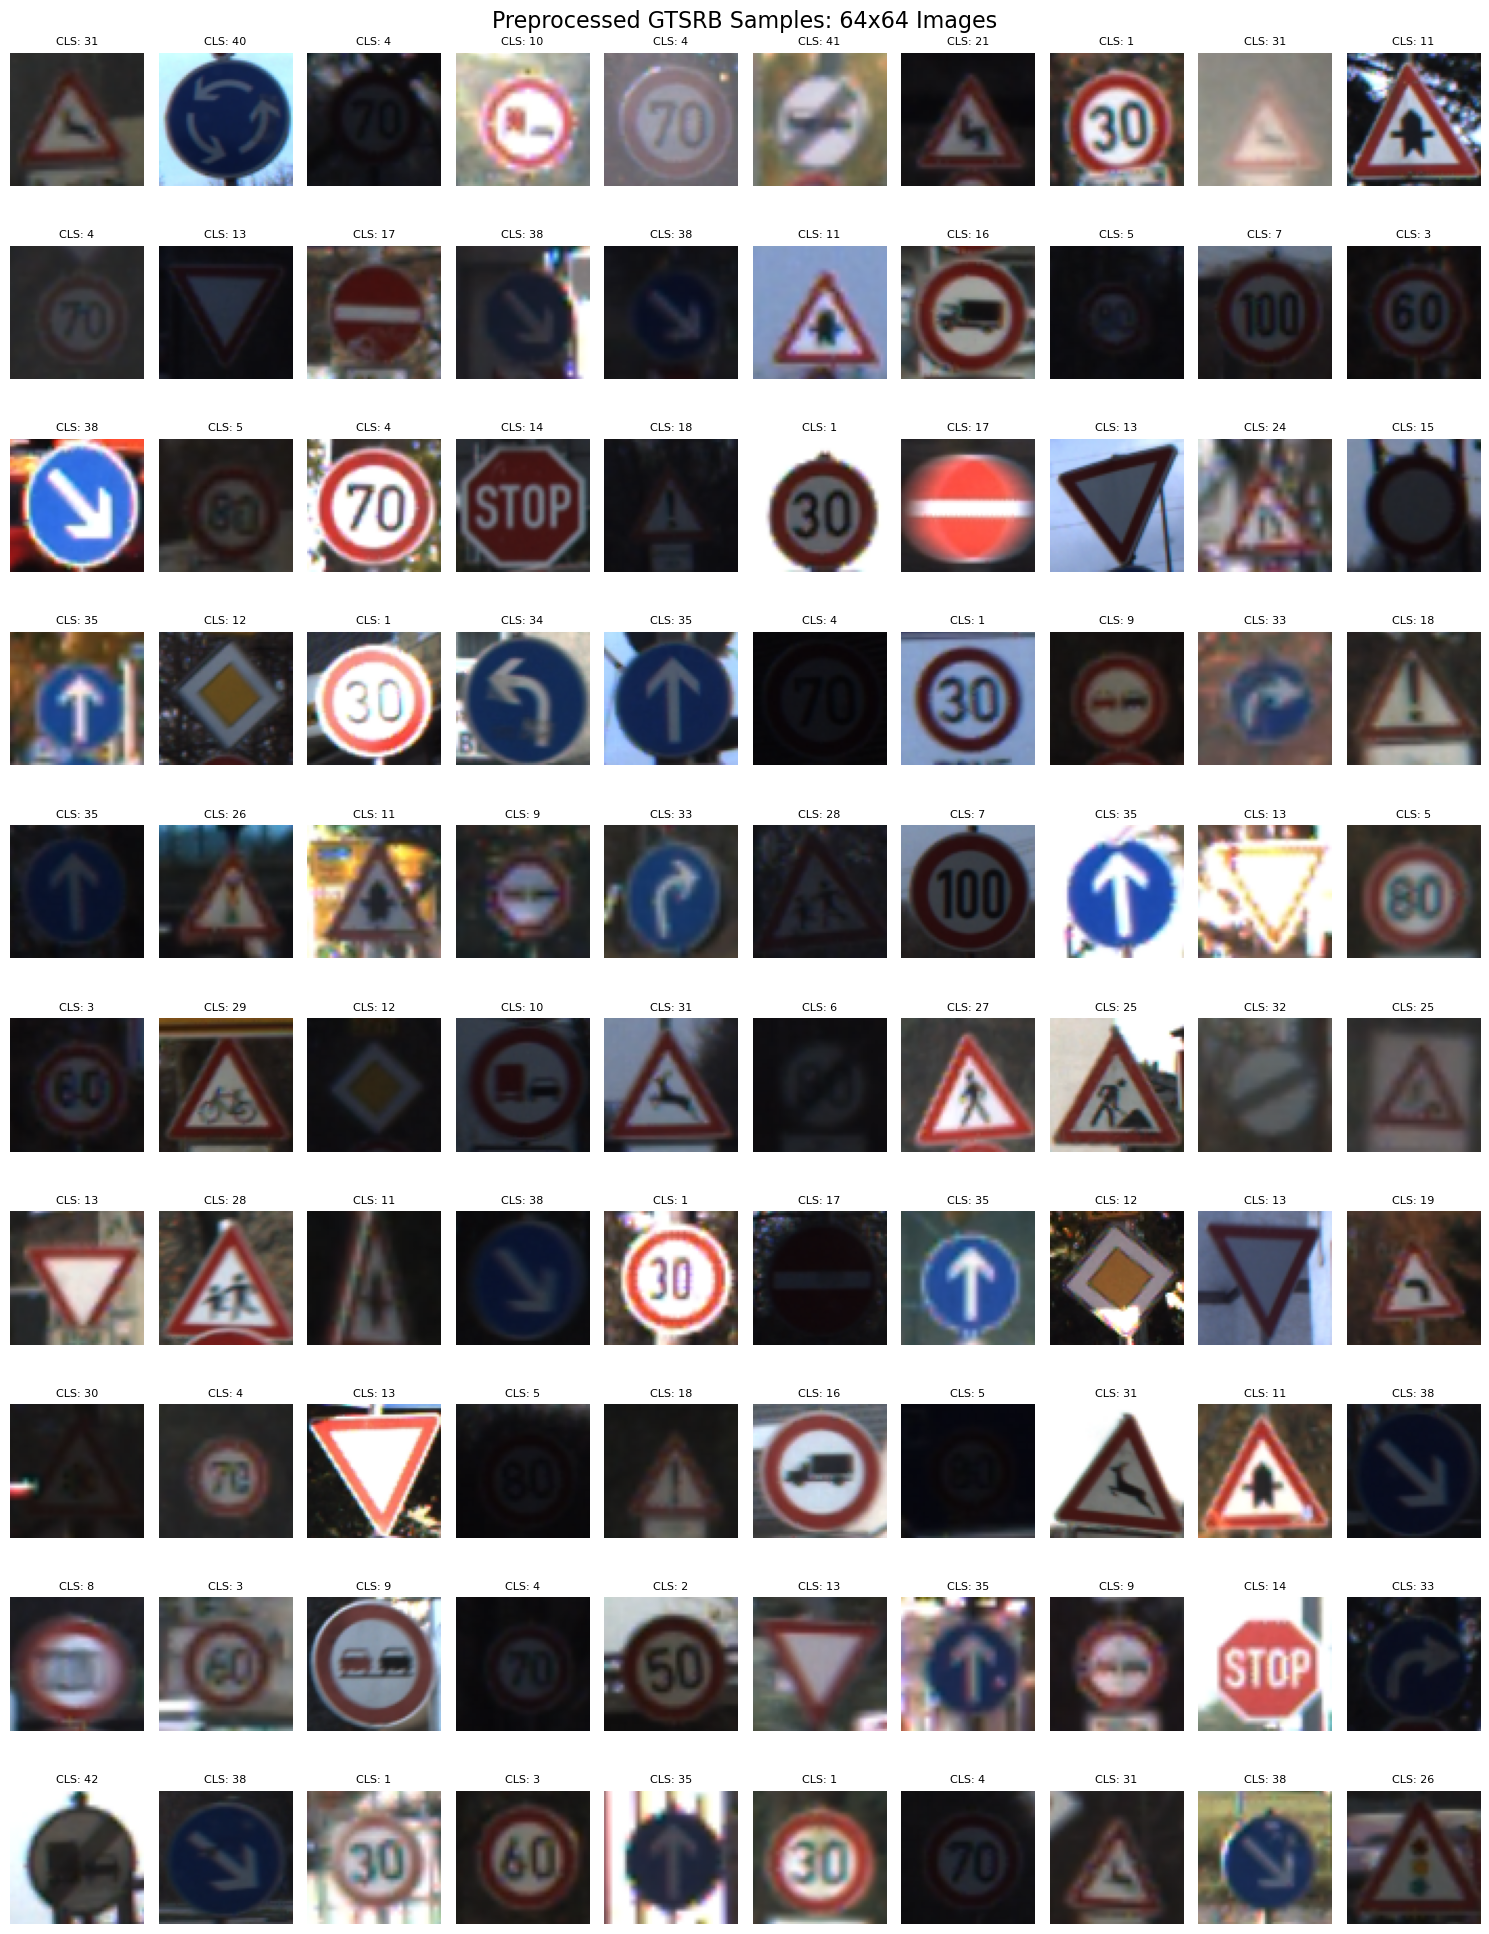

In [10]:
mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
std = torch.tensor(IMAGENET_STD).view(3, 1, 1)

def denormalize(image):
    """
    Reverts ImageNet normalization for visualization.
    The output is clipped to [0, 1], which is the valid range for matplotlib.
    """
    return (image * std + mean).clamp(0, 1)

num_samples = 100
random_indices = np.random.choice(len(ds_train), num_samples, replace=False)

plt.figure(figsize=(15, 20))

for idx, sample_idx in enumerate(random_indices):
    image, label = ds_train[sample_idx]

    plt.subplot(10, 10, idx + 1)
    plt.imshow(denormalize(image).permute(1, 2, 0))
    plt.title(f"CLS: {label}", fontsize=8)
    plt.axis("off")

plt.suptitle("Preprocessed GTSRB Samples: 64x64 Images", fontsize=16)
plt.tight_layout()
plt.show()


---
### Exercise 1.2: A Stable and Reproducible Baseline

In this exercise you should implement code to use a pretrained network as a *feature extractor* that, instead of *classifying* images in input, should return the *feature representation* from the last layer of the pretrained model before the classifier. These features, extracted from the train set, should be used to train a *classical* model for classification (e.g. an SVM, a Nearest Neighbor, or a Linear Discriminant classifier from Scikit-learn). Evaluate the performance of this baseline model on the features extracted from the test set.

Available Pretrained Models

In [11]:
from torchvision.models import list_models, get_model

# Check that ResNet-18 is available among torchvision pretrained models.
available_models = list_models()
print(f"Number of available torchvision models: {len(available_models)}")
print(f"Is ResNet-18 available? {'resnet18' in available_models}")

Number of available torchvision models: 121
Is ResNet-18 available? True


DataLoaders for Feature Extraction

In [12]:
from torch.utils.data import DataLoader

batch_size = 1024

# The feature extraction step is inference-only, so shuffle is not needed.
# num_workers parallelizes image loading and preprocessing on the CPU.
num_workers = 4
pin_memory = torch.cuda.is_available()

dl_train = DataLoader(
    ds_train,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=pin_memory,
    persistent_workers=True if num_workers > 0 else False
)

dl_test = DataLoader(
    ds_test,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=pin_memory,
    persistent_workers=True if num_workers > 0 else False
)

print(f"Train batches: {len(dl_train)}")
print(f"Test batches:  {len(dl_test)}")

Train batches: 27
Test batches:  13


Loading ResNet-18 as a Feature Extractor


In [13]:
import torch.nn as nn
from torchvision.models import get_model

model = get_model("resnet18", weights="DEFAULT")

# Replace the final ImageNet classifier with an identity layer.
# The network now returns the 512-dimensional representation before classification.
model.fc = nn.Identity()

model = model.to(device)
model.eval()

print(model.fc)

Identity()


Feature Extraction Function


In [14]:
import os
import time
from tqdm import tqdm

FEATURE_CACHE_PATH = "resnet18_gtsrb_features_64x64.pt"

def extract_features(model, dataloader, device):
    """
    Extract feature vectors and labels using a pretrained CNN.

    The model is used only in inference mode. The returned tensors are stored
    on CPU so that they can be used directly by scikit-learn models.
    """
    model.eval()

    all_features = []
    all_labels = []

    start_time = time.time()

    with torch.inference_mode():
        for images, labels in tqdm(dataloader):
            images = images.to(device, non_blocking=True)

            features = model(images)

            all_features.append(features.cpu())
            all_labels.append(labels.cpu())

    all_features = torch.vstack(all_features)
    all_labels = torch.cat(all_labels)

    elapsed_time = time.time() - start_time
    print(f"Feature extraction completed in {elapsed_time:.2f} seconds")

    return all_features, all_labels


if os.path.exists(FEATURE_CACHE_PATH):
    print("Loading cached features...")

    cached = torch.load(FEATURE_CACHE_PATH, map_location="cpu")

    train_feats = cached["train_feats"]
    train_classes = cached["train_classes"]
    test_feats = cached["test_feats"]
    test_classes = cached["test_classes"]

else:
    print("Extracting features with ResNet-18...")

    train_feats, train_classes = extract_features(
        model=model,
        dataloader=dl_train,
        device=device
    )

    test_feats, test_classes = extract_features(
        model=model,
        dataloader=dl_test,
        device=device
    )

    torch.save(
        {
            "train_feats": train_feats,
            "train_classes": train_classes,
            "test_feats": test_feats,
            "test_classes": test_classes,
        },
        FEATURE_CACHE_PATH
    )

    print(f"Features saved to {FEATURE_CACHE_PATH}")


print(f"Training features shape: {train_feats.shape}")
print(f"Training labels shape:   {train_classes.shape}")
print(f"Test features shape:     {test_feats.shape}")
print(f"Test labels shape:       {test_classes.shape}")

Loading cached features...
Training features shape: torch.Size([26640, 512])
Training labels shape:   torch.Size([26640])
Test features shape:     torch.Size([12630, 512])
Test labels shape:       torch.Size([12630])


In [15]:
#Checking the Test Dataset

ds_test

Dataset GTSRB
    Number of datapoints: 12630
    Root location: data/
    StandardTransform
Transform: Compose(
                 Resize(size=[70], interpolation=InterpolationMode.BILINEAR, antialias=True)
                 CenterCrop(size=(64, 64))
                 ToImage()
                 ToDtype(scale=True)
                 Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], inplace=False)
           )

Training a Linear SVM Classifier

In [16]:
from sklearn.svm import SVC

# We use a linear SVM because deep features extracted from a pretrained CNN
# are often already reasonably linearly separable.

svc = SVC(kernel="linear")

svc.fit(
    train_feats.numpy(),
    train_classes.numpy()
)

svc

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [17]:
from sklearn.metrics import classification_report, accuracy_score

test_predictions = svc.predict(test_feats.numpy())

baseline_accuracy = accuracy_score(
    test_classes.numpy(),
    test_predictions
)

print(f"Baseline accuracy: {baseline_accuracy:.4f}")

print(
    classification_report(
        test_classes.numpy(),
        test_predictions,
        digits=4,
        zero_division=0
    )
)

Baseline accuracy: 0.6412
              precision    recall  f1-score   support

           0     0.2083    0.1667    0.1852        60
           1     0.5216    0.6889    0.5937       720
           2     0.4786    0.4920    0.4852       750
           3     0.3412    0.3556    0.3482       450
           4     0.6028    0.5818    0.5921       660
           5     0.5387    0.5190    0.5287       630
           6     0.9764    0.8267    0.8953       150
           7     0.5795    0.5267    0.5518       450
           8     0.4603    0.3733    0.4123       450
           9     0.9122    0.7792    0.8404       480
          10     0.8432    0.8879    0.8649       660
          11     0.4760    0.5905    0.5271       420
          12     0.9480    0.9768    0.9622       690
          13     0.9532    0.9903    0.9714       720
          14     0.9080    0.8407    0.8731       270
          15     0.9902    0.9667    0.9783       210
          16     0.8857    0.8267    0.8552       150
 

---
### Exercise 1.3: A Fine-tuning Baseline

In this exercise you should try to *improve* on the stable baseline given by the feature extraction + SVM (or whatever) classifier you produced in the previous lecture. To do this, you should *fine-tune* the ResNet-18 (or whatever model you chose) to solve the new classification task.

To do this, you could proceed by:
1. Loading the ResNet-18 (or whatever) model and replacing the final FC layer (the classifier) with a *new* classifier. This could be a single Linear layer, or could be an MLP.
2. Training the resulting model on the GTSRB dataset for a few epochs.
3. Evaluating the resulting performance.

Some things you should probably consider (especially thinking about the *next* exercise):
+ You should be monitoring not only the loss on the training set, but also a *validation* loss on an *independent* validation set. Split the training set into two datasets: one with, say, 80% of the original training samples, and another with the remaining 20%. You can use this smaller set to monitor performance and check for *overfitting*.
+ Maybe the best strategy is to not fine-tune *all* layers, but only the last few. Think about *selectively* fine-tuning layers of the network.
+ Maybe a *single* linear layer isn't the best option for the classifier. Think about using an MLP instead.

Import

In [18]:

import os
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from torchvision.models import get_model
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import importlib
import engine

importlib.reload(engine)
from engine import train_and_evaluate

In [19]:
import wandb

# This will ask for the API key interactively if needed.
# Do not hard-code the API key inside the notebook.
wandb.login()

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\checc\_netrc.
wandb: Currently logged in as: francesco-faggioli (francesco-faggioli-university-of-florence) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

Grouped and Stratified Train/Validation Split

In [20]:
TRACK_SIZE = 30
NUM_CLASSES = 43

labels_all = df_stats["CLS"].to_numpy()
num_samples = len(ds_train)

assert num_samples == len(labels_all), "Mismatch between dataset and metadata length."
assert num_samples % TRACK_SIZE == 0, "Dataset length is not divisible by track size."

num_tracks = num_samples // TRACK_SIZE
track_ids = np.arange(num_tracks)

# Check that each track contains only one class.
track_labels = []

for track_id in track_ids:
    start = track_id * TRACK_SIZE
    end = start + TRACK_SIZE

    labels_in_track = labels_all[start:end]
    unique_labels = np.unique(labels_in_track)

    assert len(unique_labels) == 1, (
        f"Track {track_id} contains multiple classes: {unique_labels}"
    )

    track_labels.append(unique_labels[0])

track_labels = np.array(track_labels)

train_tracks, val_tracks = train_test_split(
    track_ids,
    test_size=0.20,
    random_state=SEED,
    stratify=track_labels
)

train_indices = np.concatenate([
    np.arange(track_id * TRACK_SIZE, (track_id + 1) * TRACK_SIZE)
    for track_id in train_tracks
])

val_indices = np.concatenate([
    np.arange(track_id * TRACK_SIZE, (track_id + 1) * TRACK_SIZE)
    for track_id in val_tracks
])

ds_train_real = Subset(ds_train, train_indices)
ds_val = Subset(ds_train, val_indices)

print(f"Training subset size:   {len(ds_train_real)}")
print(f"Validation subset size: {len(ds_val)}")
print(f"Test set size:          {len(ds_test)}")

Training subset size:   21300
Validation subset size: 5340
Test set size:          12630


Checking Class Distribution after the Split

In [21]:
train_labels = labels_all[train_indices]
val_labels = labels_all[val_indices]

train_class_counts = np.bincount(train_labels, minlength=NUM_CLASSES)
val_class_counts = np.bincount(val_labels, minlength=NUM_CLASSES)

print("Minimum train samples per class:", train_class_counts.min())
print("Minimum val samples per class:  ", val_class_counts.min())
print("Maximum train samples per class:", train_class_counts.max())
print("Maximum val samples per class:  ", val_class_counts.max())

print("Classes missing in train:", np.where(train_class_counts == 0)[0])
print("Classes missing in val:  ", np.where(val_class_counts == 0)[0])

Minimum train samples per class: 120
Minimum val samples per class:   30
Maximum train samples per class: 1200
Maximum val samples per class:   300
Classes missing in train: []
Classes missing in val:   []


In [22]:
class_weights_global = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(NUM_CLASSES),
    y=train_labels
)

print("Class weights computed.")
print(f"Number of weights: {len(class_weights_global)}")
print(f"Min weight: {class_weights_global.min():.4f}")
print(f"Max weight: {class_weights_global.max():.4f}")

Class weights computed.
Number of weights: 43
Min weight: 0.4128
Max weight: 4.1279


DataLoaders for Fine-tuning

In [23]:

batch_size_base = 64
num_workers = 4
use_pin_memory = device.type == "cuda"

dl_train_real = DataLoader(
    ds_train_real,
    batch_size=batch_size_base,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=use_pin_memory,
    persistent_workers=True if num_workers > 0 else False
)

dl_val = DataLoader(
    ds_val,
    batch_size=batch_size_base,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=use_pin_memory,
    persistent_workers=True if num_workers > 0 else False
)

dl_test = DataLoader(
    ds_test,
    batch_size=batch_size_base,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=use_pin_memory,
    persistent_workers=True if num_workers > 0 else False
)

print(f"Train batches: {len(dl_train_real)}")
print(f"Val batches:   {len(dl_val)}")
print(f"Test batches:  {len(dl_test)}")

Train batches: 333
Val batches:   84
Test batches:  198


ResNet-18 for GTSRB

In [24]:

def get_fresh_resnet18(num_classes=43, freeze_backbone=True, unfreeze_layer4=False):
    """
    Creates a fresh ResNet-18 pretrained on ImageNet and adapts it to GTSRB.

    Args:
        num_classes: number of GTSRB classes.
        freeze_backbone: if True, the convolutional backbone is frozen.
        unfreeze_layer4: if True, the last residual block is trainable.
    """
    model = get_model("resnet18", weights="DEFAULT")

    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)

    if freeze_backbone:
        for name, param in model.named_parameters():
            param.requires_grad = False

        for name, param in model.named_parameters():
            if name.startswith("fc"):
                param.requires_grad = True

            if unfreeze_layer4 and name.startswith("layer4"):
                param.requires_grad = True

    else:
        for param in model.parameters():
            param.requires_grad = True

    return model.to(device)


def print_trainable_parameters(model):
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    print(f"Total parameters:     {total_params:,}")
    print(f"Trainable parameters: {trainable_params:,}")
    print(f"Trainable ratio:      {100 * trainable_params / total_params:.2f}%")

Evaluation Utility

In [25]:

def evaluate_model(model, dataloader, device, title="Confusion Matrix"):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.inference_mode():
        for inputs, labels in dataloader:
            inputs = inputs.to(device, non_blocking=True)

            outputs = model(inputs)
            preds = outputs.argmax(dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)

    print(f"Accuracy: {acc:.4f}")
    print(
        classification_report(
            all_labels,
            all_preds,
            digits=4,
            zero_division=0
        )
    )

    cm = confusion_matrix(all_labels, all_preds)

    fig, ax = plt.subplots(figsize=(14, 12))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(
        cmap="Blues",
        ax=ax,
        values_format="d",
        colorbar=False
    )

    plt.title(title)
    plt.tight_layout()
    plt.show()

    return acc, np.array(all_labels), np.array(all_preds)